# 13: Root Cause, Anomaly, and Distribution Change

The previous GCM notebooks used structural causal models for simulation, intervention, and counterfactual questions. We use the same GCM idea for a different class of problems: **why did something look abnormal or shift over time?**

We will use DoWhy GCM tools for two related but distinct tasks:

- **Anomaly attribution:** Given a small number of unusual rows, which upstream variables explain why the target outcome is anomalous?
- **Distribution-change attribution:** Given an old dataset and a new dataset, which causal mechanisms or upstream variables explain the change in the target distribution?

These questions are common in monitoring, operations, experimentation diagnostics, product analytics, risk systems, and model-quality investigations. The notebook stays synthetic so the story is easy to follow, but the workflow is general.

## Learning Goals

By the end, you should be able to:

- Explain the difference between row-level anomaly attribution and population-level distribution-change attribution.
- Fit an invertible GCM that supports anomaly attribution.
- Use `gcm.anomaly_scores` to score unusual observations node by node.
- Use `gcm.attribute_anomalies` to attribute target anomalies to upstream nodes.
- Use `gcm.distribution_change` to attribute a target distribution shift between old and new data.
- Use `gcm.distribution_change_robust` as a complementary mean-shift attribution method.
- Report root-cause results with the assumptions and limitations that make them credible.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use mostly simulated or semi-synthetic observational datasets to study **Root Cause, Anomaly, And Distribution Change**. DoWhy is mainly about causal modeling discipline: graph, estimand, estimator, and refuter. A controlled dataset lets us show how a change in assumptions changes the estimand and the credibility of the estimate.

Read each row as an observed unit in a business or policy system. The treatment, outcome, common causes, instruments, mediators, or anomaly indicators are named to mirror applied causal workflows rather than abstract textbook variables. The experiment treats distribution change and anomalies as causal diagnostic problems. The data are arranged so root-cause claims can be checked against the design.

The simulation is not meant to make the problem easy. It is meant to expose the assumptions that would be hidden in real data, where the true counterfactual outcome is unavailable.


## Mathematical Foundation

<!-- math-foundation-note -->

Root-cause analysis compares a baseline distribution $P_0$ to a shifted distribution $P_1$. A node-level contribution asks how much changing one mechanism explains

$$
P_1(Y)-P_0(Y).
$$

In a structural model, this means asking which assignment $X_j:=f_j(\cdot)$ changed. The graph supplies the ordering needed to distinguish symptoms from plausible sources.


## Why Root Cause Analysis is a Causal Problem

A dashboard can tell us that a metric moved. A predictive model can tell us which variables are associated with that movement. A causal graph tries to answer a more operational question:

> Which upstream changes would explain the observed downstream anomaly if the graph and mechanisms were correct?

That is a causal question because downstream variables can be symptoms rather than causes. For example, low session depth and low future value may appear together, but low session depth might be caused by an earlier latency spike or catalog-quality problem. A GCM uses the graph to keep those upstream and downstream roles separate.




## Tutorial Workflow

#### Setup

The code below imports the libraries, configures output folders, suppresses known non-actionable warnings, and disables DoWhy GCM progress bars. The notebook uses `InvertibleStructuralCausalModel` because anomaly attribution needs to recover row-level noise for non-root nodes.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import warnings

# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*setParseAction.*deprecated.*")
warnings.filterwarnings("ignore", message=".*copy keyword is deprecated.*")
warnings.filterwarnings("ignore", message=".*disp.*iprint.*L-BFGS-B.*")
warnings.filterwarnings("ignore", message=".*variables are assumed unobserved.*")
warnings.filterwarnings("ignore", module="pydot.dot_parser")

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)

# Compatibility shim for DoWhy estimators written against older pandas Series integer indexing.
if not getattr(pd.Series, "_dowhy_integer_position_patch", False):
    _original_series_getitem = pd.Series.__getitem__

    def _dowhy_series_getitem_compat(self, key):
        try:
            return _original_series_getitem(self, key)
        except KeyError:
            if isinstance(key, int) and key not in self.index:
                return self.iloc[key]
            raise

    pd.Series.__getitem__ = _dowhy_series_getitem_compat
    pd.Series._dowhy_integer_position_patch = True
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Compatibility shim for DoWhy versions that expect the older NetworkX d_separated API.
if not hasattr(nx.algorithms, "d_separated"):
    from networkx.algorithms.d_separation import is_d_separator
    nx.algorithms.d_separated = is_d_separator

from IPython.display import display
from dowhy import gcm
import dowhy

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

gcm.config.show_progress_bars = False

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"DoWhy version: {getattr(dowhy, '__version__', 'unknown')}")
print(f"Figures will be saved to: {FIGURE_DIR.resolve()}")
print(f"Tables will be saved to: {TABLE_DIR.resolve()}")


DoWhy version: 0.12
Figures will be saved to: /home/apex/Documents/portfolio/notebooks/tutorials/dowhy/outputs/figures
Tables will be saved to: /home/apex/Documents/portfolio/notebooks/tutorials/dowhy/outputs/tables


The environment is ready once the DoWhy version and output folders print. Every saved output in this lesson uses a `13_` prefix.

This is a reproducibility check rather than causal evidence. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


### Problem Map

Root-cause work can mean several different things. The next table separates the tasks covered in this lesson so the estimand does not get fuzzy.

| task | DoWhy function | input | question answered |
| --- | --- | --- | --- |
| node anomaly scoring | gcm.anomaly_scores | a fitted GCM and anomalous rows | Which nodes look individually unusual, conditional on their parents? |
| target anomaly attribution | gcm.attribute_anomalies | a fitted invertible GCM, target node, and anomalous rows | Which upstream nodes contribute to the target anomaly for each row? |
| distribution-change attribution | gcm.distribution_change | old data, new data, target node, and a causal graph | Which node-level changes explain the target distribution shift? |
| robust mean-shift attribution | gcm.distribution_change_robust | old data, new data, target node, and a causal graph | Which variables explain the change in a selected target functional such as the mean? |


The key distinction is row versus population. Anomaly attribution explains specific unusual rows; distribution-change attribution explains why a target distribution changed between two samples.

### Teaching Scenario

We will simulate a service-quality system with six observed variables:

- `traffic_intent`: upstream demand or user intent.
- `catalog_health`: availability and match quality of useful items.
- `latency_pressure`: infrastructure or response-time pressure.
- `recommendation_quality`: quality of the ranked experience.
- `session_depth`: short-term engagement depth.
- `future_value`: later value or retention-like outcome.

The target for root-cause analysis is `future_value`. In the old period the system is healthy. In the new period, catalog health declines, latency pressure increases, and recommendation quality receives an additional mechanism penalty. This gives us a realistic example where both root distributions and a downstream mechanism change.

| column | role | plain meaning | root-cause note |
| --- | --- | --- | --- |
| traffic_intent | root context variable | Baseline demand or intent entering the system. | Can make outcomes high or low, but is not caused by other variables in this graph. |
| catalog_health | root quality variable | How healthy and relevant the available catalog is. | A decline can propagate into recommendation quality and future value. |
| latency_pressure | root reliability variable | Higher values mean slower or more strained service conditions. | A spike can harm recommendation quality, session depth, and future value. |
| recommendation_quality | intermediate mechanism | Quality of the ranked or selected experience. | Can be a cause of downstream symptoms or a symptom of upstream problems. |
| session_depth | mediating outcome | Short-term engagement depth during the session. | Often moves with future value, but sits downstream of quality and latency. |
| future_value | target outcome | Later value we want to explain when it becomes anomalous or shifts. | The target is explained by upstream nodes, not used as a root cause of itself except for residual noise. |


The root-cause note column is important. A downstream symptom can be useful evidence, but the graph determines whether it should be treated as a candidate cause or as part of the propagation path.

#### Simulate Old and New System Periods

The helper below creates data for an old healthy period and a new shifted period. The new period has three changes: lower catalog health, higher latency pressure, and an additional recommendation-quality penalty.

In [2]:
# Define reusable helpers for the Simulate Old And New System Periods section.
def simulate_service_quality_data(n, period, rng):
    """
    Generate a service-quality dataset for either the old or new period.
    
    Parameters
    ----------
    n : object
        Number of simulated observations, rows, or repetitions.
    period : object
        Time period at which the panel or longitudinal effect is evaluated.
    rng : np.random.Generator
        Random number generator that makes simulation reproducible.
    
    Returns
    -------
    pd.DataFrame
        Dataset table for simulate service quality data, with the variables needed by the tutorial design.
    """
    if period == "old":
        traffic_intent = rng.normal(0.00, 1.00, size=n)
        catalog_health = rng.normal(0.00, 1.00, size=n)
        latency_pressure = rng.normal(0.00, 1.00, size=n)
        recommendation_penalty = 0.00
    elif period == "new":
        traffic_intent = rng.normal(0.05, 1.00, size=n)
        catalog_health = rng.normal(-0.55, 1.00, size=n)
        latency_pressure = rng.normal(0.65, 1.00, size=n)
        recommendation_penalty = -0.25
    else:
        raise ValueError("period must be either 'old' or 'new'")

    recommendation_quality = (
        0.55 * traffic_intent
        + 0.65 * catalog_health
        - 0.55 * latency_pressure
        + recommendation_penalty
        + rng.normal(0, 0.45, size=n)
    )
    session_depth = (
        0.70 * recommendation_quality
        + 0.35 * traffic_intent
        - 0.35 * latency_pressure
        + rng.normal(0, 0.50, size=n)
    )
    future_value = (
        0.45 * recommendation_quality
        + 0.65 * session_depth
        + 0.25 * traffic_intent
        - 0.25 * latency_pressure
        + rng.normal(0, 0.55, size=n)
    )

    return pd.DataFrame(
        {
            "period": period,
            "traffic_intent": traffic_intent,
            "catalog_health": catalog_health,
            "latency_pressure": latency_pressure,
            "recommendation_quality": recommendation_quality,
            "session_depth": session_depth,
            "future_value": future_value,
        }
    )

old_data = simulate_service_quality_data(2_000, "old", rng)
new_data = simulate_service_quality_data(2_000, "new", rng)
combined_data = pd.concat([old_data, new_data], ignore_index=True)

old_data.to_csv(TABLE_DIR / "13_old_period_data.csv", index=False)
new_data.to_csv(TABLE_DIR / "13_new_period_data.csv", index=False)
combined_data.to_csv(TABLE_DIR / "13_combined_period_data.csv", index=False)

display(combined_data.head())


,period,traffic_intent,catalog_health,latency_pressure,recommendation_quality,session_depth,future_value
0,old,-0.7931,-0.4100,1.4960,-1.3631,-1.8151,-2.4419
1,old,0.2406,-0.4360,-0.9171,-0.1403,0.5292,-0.2684
2,old,-1.8963,-0.0217,0.0238,-1.2923,-1.5030,-2.9105
3,old,1.3958,0.1183,-0.9931,1.6108,1.2316,2.0909
4,old,0.6383,-0.2030,0.4032,-0.2672,-0.2622,0.4969


The `period` column is kept for EDA and saved outputs, but the GCM itself will be fit on the causal variables. The period label is not a causal node in this graph.




## Diagnostics and Interpretation

### Basic Period Comparison

Before using GCM tools, compare old and new summaries. This tells us the visible symptom: what changed in the new period?

In [3]:
# Save the artifacts produced by the Basic Period Comparison section.
causal_columns = [
    "traffic_intent",
    "catalog_health",
    "latency_pressure",
    "recommendation_quality",
    "session_depth",
    "future_value",
]

period_summary = (
    combined_data.groupby("period")[causal_columns]
    .agg(["mean", "std"])
    .T
    .reset_index()
    .rename(columns={"level_0": "variable", "level_1": "summary"})
)

mean_shift = (
    combined_data.groupby("period")[causal_columns]
    .mean()
    .T
    .assign(mean_change_new_minus_old=lambda frame: frame["new"] - frame["old"])
    .reset_index(names="variable")
)

period_summary.to_csv(TABLE_DIR / "13_period_summary.csv", index=False)
mean_shift.to_csv(TABLE_DIR / "13_mean_shift_summary.csv", index=False)

display(mean_shift)


period,variable,new,old,mean_change_new_minus_old
0,traffic_intent,0.0408,-0.0342,0.0750
1,catalog_health,-0.5601,0.0020,-0.5621
2,latency_pressure,0.6696,0.0296,0.6399
3,recommendation_quality,-0.9494,-0.0354,-0.9140
4,session_depth,-0.8827,-0.0493,-0.8334
5,future_value,-1.1494,-0.0686,-1.0808


The new period shows lower catalog health, higher latency pressure, lower recommendation quality, lower session depth, and lower future value. That is the symptom pattern the causal tools will try to decompose.

#### Plot Old versus New Distributions

Distribution plots show whether the shift is broad or concentrated in the tails. We focus on the main upstream suspects and the target outcome.

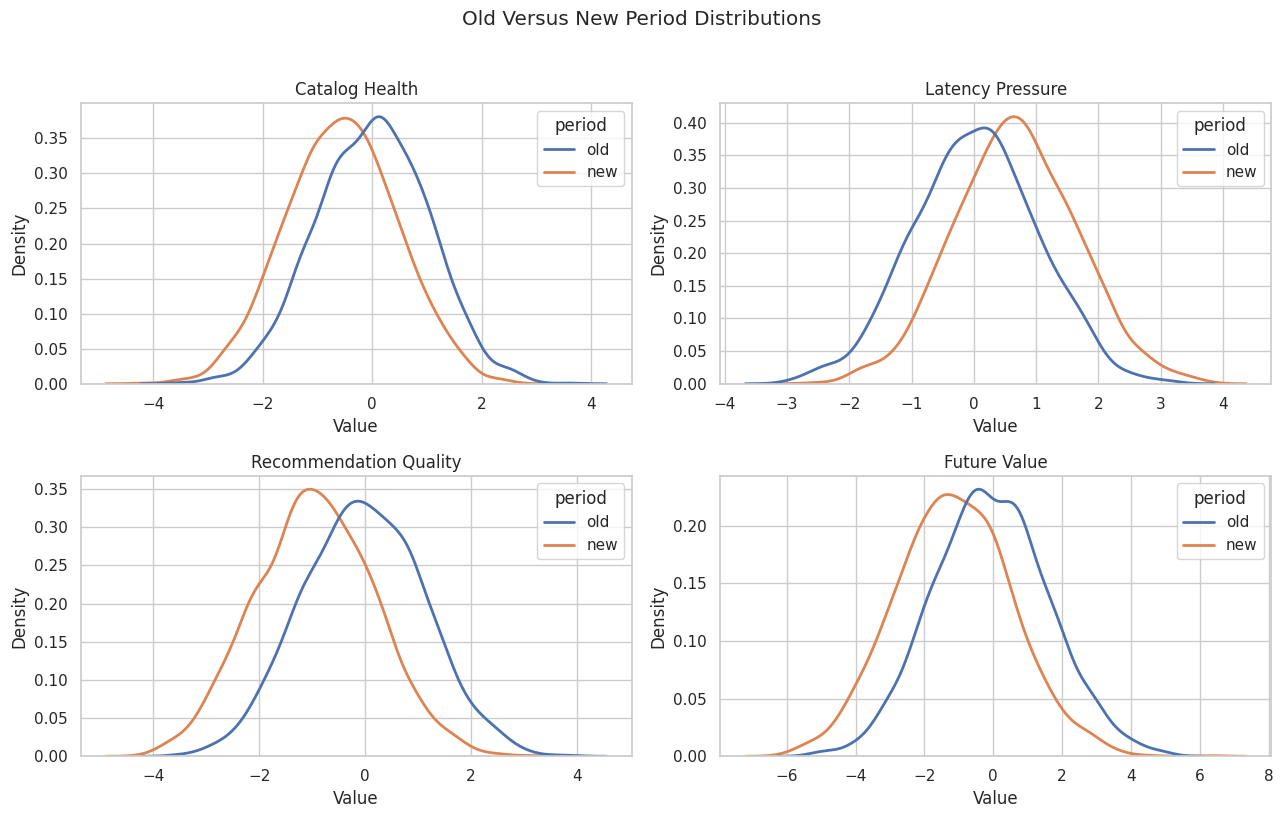

In [4]:
period_plot_df = combined_data.melt(
    id_vars="period",
    value_vars=["catalog_health", "latency_pressure", "recommendation_quality", "future_value"],
    var_name="variable",
    value_name="value",
)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=False)
for ax, variable in zip(axes.flat, ["catalog_health", "latency_pressure", "recommendation_quality", "future_value"]):
    sns.kdeplot(
        data=period_plot_df[period_plot_df["variable"] == variable],
        x="value",
        hue="period",
        common_norm=False,
        linewidth=2,
        ax=ax,
    )
    ax.set_title(variable.replace("_", " ").title())
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")

fig.suptitle("Old Versus New Period Distributions", y=1.02)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "13_old_vs_new_distributions.png", dpi=160, bbox_inches="tight")
plt.show()


The distribution view makes the shift visible: catalog health moves left, latency pressure moves right, and the downstream target moves left. The GCM sections ask how much each upstream change contributes to the target movement.



### Specify the Causal Graph

The graph separates root conditions from downstream mechanisms. `traffic_intent`, `catalog_health`, and `latency_pressure` are root nodes. Recommendation quality, session depth, and future value are generated downstream.

In [5]:
causal_edges = [
    ("traffic_intent", "recommendation_quality"),
    ("catalog_health", "recommendation_quality"),
    ("latency_pressure", "recommendation_quality"),
    ("traffic_intent", "session_depth"),
    ("recommendation_quality", "session_depth"),
    ("latency_pressure", "session_depth"),
    ("traffic_intent", "future_value"),
    ("recommendation_quality", "future_value"),
    ("session_depth", "future_value"),
    ("latency_pressure", "future_value"),
]

causal_graph = nx.DiGraph(causal_edges)
edge_table = pd.DataFrame(causal_edges, columns=["cause", "effect"])
edge_table.to_csv(TABLE_DIR / "13_causal_graph_edges.csv", index=False)
display(edge_table)


,cause,effect
0,traffic_intent,recommendation_quality
1,catalog_health,recommendation_quality
2,latency_pressure,recommendation_quality
3,traffic_intent,session_depth
4,recommendation_quality,session_depth
5,latency_pressure,session_depth
6,traffic_intent,future_value
7,recommendation_quality,future_value
8,session_depth,future_value
9,latency_pressure,future_value


The graph lets latency pressure affect future value both directly and indirectly through recommendation quality and session depth. That is why root-cause attribution can differ from a simple correlation ranking.

#### Visualize the Root-Cause Graph

The diagram places root variables on the left and downstream outcomes on the right. Arrows are drawn before node labels so they stop visually behind the labeled boxes.

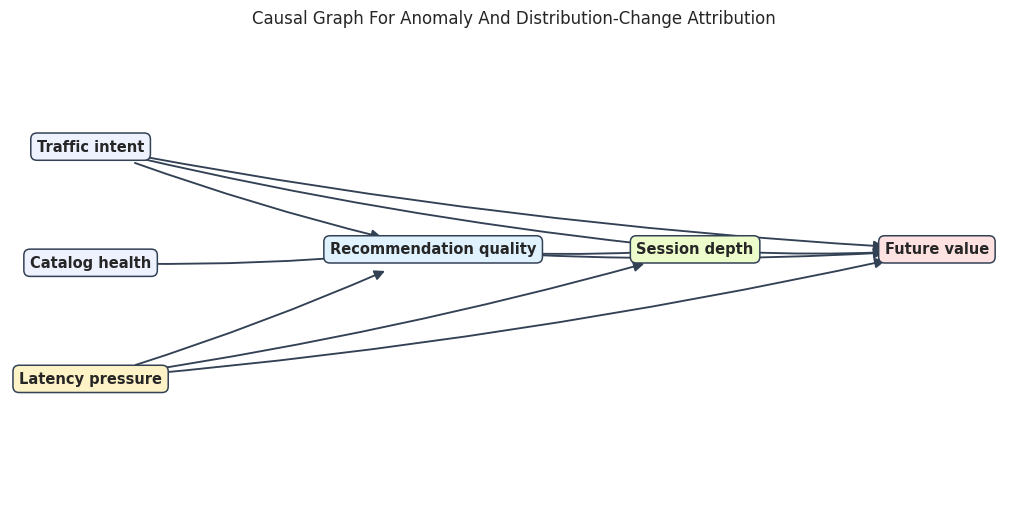

In [6]:
# Build and label the diagnostic visualization for the Visualize The Root-Cause Graph section.
positions = {
    "traffic_intent": (0.08, 0.78),
    "catalog_health": (0.08, 0.52),
    "latency_pressure": (0.08, 0.26),
    "recommendation_quality": (0.42, 0.55),
    "session_depth": (0.68, 0.55),
    "future_value": (0.92, 0.55),
}
node_labels = {
    "traffic_intent": "Traffic intent",
    "catalog_health": "Catalog health",
    "latency_pressure": "Latency pressure",
    "recommendation_quality": "Recommendation quality",
    "session_depth": "Session depth",
    "future_value": "Future value",
}
node_colors = {
    "traffic_intent": "#eef2ff",
    "catalog_health": "#eef2ff",
    "latency_pressure": "#fef3c7",
    "recommendation_quality": "#e0f2fe",
    "session_depth": "#ecfccb",
    "future_value": "#fee2e2",
}

fig, ax = plt.subplots(figsize=(13, 5.8))
ax.set_axis_off()

for source, target in causal_edges:
    ax.annotate(
        "",
        xy=positions[target],
        xytext=positions[source],
        arrowprops=dict(
            arrowstyle="-|>",
            color="#334155",
            linewidth=1.35,
            shrinkA=34,
            shrinkB=38,
            mutation_scale=15,
            connectionstyle="arc3,rad=0.035",
        ),
    )

for node, (x, y) in positions.items():
    ax.text(
        x,
        y,
        node_labels[node],
        ha="center",
        va="center",
        fontsize=10.5,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.42",
            facecolor=node_colors[node],
            edgecolor="#334155",
            linewidth=1.1,
        ),
    )

ax.set_title("Causal Graph For Anomaly And Distribution-Change Attribution", pad=18)
fig.savefig(FIGURE_DIR / "13_root_cause_graph.png", dpi=160, bbox_inches="tight")
plt.show()


The graph shows why `session_depth` can be a symptom rather than the original root cause. It is downstream of recommendation quality and latency pressure.

#### Build and Fit the Reference GCM

We fit the reference GCM on the old healthy period. Root nodes use empirical distributions. Non-root nodes use additive-noise mechanisms with linear regressors, which match the structural form used in this example data and support anomaly attribution.

In [7]:
reference_model = gcm.InvertibleStructuralCausalModel(causal_graph)

root_nodes = ["traffic_intent", "catalog_health", "latency_pressure"]
child_nodes = ["recommendation_quality", "session_depth", "future_value"]

for node in root_nodes:
    reference_model.set_causal_mechanism(node, gcm.EmpiricalDistribution())

for node in child_nodes:
    reference_model.set_causal_mechanism(
        node,
        gcm.AdditiveNoiseModel(gcm.ml.create_linear_regressor()),
    )

mechanism_table = pd.DataFrame(
    [
        {
            "node": node,
            "parents": ", ".join(causal_graph.predecessors(node)) or "none",
            "mechanism": type(reference_model.causal_mechanism(node)).__name__,
        }
        for node in causal_graph.nodes
    ]
)

mechanism_table.to_csv(TABLE_DIR / "13_assigned_mechanisms.csv", index=False)
display(mechanism_table)


,node,parents,mechanism
0,traffic_intent,none,EmpiricalDistribution
1,recommendation_quality,"traffic_intent, catalog_health, latency_pressure",AdditiveNoiseModel
2,catalog_health,none,EmpiricalDistribution
3,latency_pressure,none,EmpiricalDistribution
4,session_depth,"traffic_intent, recommendation_quality, latency_pressure",AdditiveNoiseModel
5,future_value,"traffic_intent, recommendation_quality, session_depth, latency_pressure",AdditiveNoiseModel


The reference model represents normal behavior. Later, anomalies and distribution shifts are judged relative to this old-period causal system.

That distinction is what makes the causal model useful: interventions propagate through linked mechanisms rather than through isolated predictive associations.
<!-- result-implication-expanded -->


#### Fit the Reference Mechanisms

The next cell estimates each node mechanism from old-period data. After fitting, the model can generate normal samples, score anomalies, and reconstruct noise for anomalous rows.

In [8]:
old_causal_data = old_data[causal_columns].copy()
new_causal_data = new_data[causal_columns].copy()

gcm.fit(reference_model, old_causal_data)

fit_status = pd.DataFrame(
    [
        {
            "node": node,
            "fitted_mechanism": type(reference_model.causal_mechanism(node)).__name__,
            "fit_period": "old",
            "has_parents": causal_graph.in_degree(node) > 0,
        }
        for node in causal_graph.nodes
    ]
)

fit_status.to_csv(TABLE_DIR / "13_reference_fit_status.csv", index=False)
display(fit_status)


,node,fitted_mechanism,fit_period,has_parents
0,traffic_intent,EmpiricalDistribution,old,False
1,recommendation_quality,AdditiveNoiseModel,old,True
2,catalog_health,EmpiricalDistribution,old,False
3,latency_pressure,EmpiricalDistribution,old,False
4,session_depth,AdditiveNoiseModel,old,True
5,future_value,AdditiveNoiseModel,old,True


The fitted model is now the baseline causal model. The next check asks whether it can reproduce the old-period distribution well enough for attribution examples.

### Check Reference Model Samples

A root-cause workflow should not skip model checks. Here we draw samples from the fitted reference model and compare them to old-period data.

In [9]:
reference_samples = gcm.draw_samples(reference_model, num_samples=len(old_causal_data))

reference_check = pd.concat(
    [
        old_causal_data.agg(["mean", "std"]).T.assign(source="old_observed"),
        reference_samples.agg(["mean", "std"]).T.assign(source="gcm_reference_sample"),
    ]
).reset_index(names="variable")

reference_check.to_csv(TABLE_DIR / "13_reference_model_sample_check.csv", index=False)
display(reference_check)

,variable,mean,std,source
0,traffic_intent,-0.0342,1.0056,old_observed
1,catalog_health,0.0020,1.0116,old_observed
2,latency_pressure,0.0296,1.0009,old_observed
3,recommendation_quality,-0.0354,1.1312,old_observed
4,session_depth,-0.0493,1.2762,old_observed
5,future_value,-0.0686,1.6661,old_observed
6,traffic_intent,-0.0430,0.9988,gcm_reference_sample
7,catalog_health,0.0337,1.0346,gcm_reference_sample
8,latency_pressure,-0.0054,0.9811,gcm_reference_sample
9,recommendation_quality,0.0014,1.1168,gcm_reference_sample


The generated sample is close to the old observed data on means and standard deviations. This gives the attribution examples a reasonable baseline. The graph still needs a separate causal argument.

#### Choose Anomalous Rows

For anomaly attribution, we select a handful of new-period rows with the lowest `future_value`. These are the rows whose downstream abnormality we want to explain using the old-period reference model.

In [10]:
anomaly_samples = (
    new_causal_data
    .nsmallest(8, "future_value")
    .reset_index(drop=True)
)

anomaly_samples.to_csv(TABLE_DIR / "13_anomaly_samples.csv", index=False)
display(anomaly_samples)

,traffic_intent,catalog_health,latency_pressure,recommendation_quality,session_depth,future_value
0,-1.6868,-1.0211,1.9740,-3.6013,-4.2767,-6.0933
1,-0.7594,-1.3497,3.3312,-3.0751,-3.8410,-5.9036
2,-1.8228,-1.9670,2.5293,-3.9185,-4.5886,-5.7084
3,-2.2549,0.2372,2.3927,-2.4273,-3.7330,-5.6638
4,-1.4953,-0.6883,1.9845,-3.1921,-3.6082,-5.5982
5,-2.1893,-0.7117,1.2206,-3.6108,-3.6397,-5.5455
6,-2.0970,-1.0511,1.0655,-2.9025,-3.9922,-5.5202
7,-1.4380,-1.1261,3.4270,-3.6518,-4.2777,-5.5121


These rows are intentionally extreme in the target outcome. The attribution question is not whether they are low; it is which upstream variables explain why they are low under the fitted causal model.



#### Score Node-Level Anomalies

`gcm.anomaly_scores` gives node-level anomaly scores for each row. For root nodes, the score is based on the marginal distribution. For non-root nodes, the score is conditional on parents, so it asks whether the node is unusual given its causal inputs.

In [11]:
anomaly_score_dict = gcm.anomaly_scores(
    reference_model,
    anomaly_samples,
    num_samples_conditional=400,
    num_samples_unconditional=400,
)

anomaly_score_table = pd.DataFrame(anomaly_score_dict).reset_index(names="anomaly_row")
anomaly_score_table.to_csv(TABLE_DIR / "13_node_level_anomaly_scores.csv", index=False)
display(anomaly_score_table)

,anomaly_row,traffic_intent,recommendation_quality,catalog_health,latency_pressure,session_depth,future_value
0,0,1.9866,2.9494,1.1982,3.1607,1.0887,2.3830
1,1,0.6421,0.0050,1.6245,5.9940,0.5958,3.2859
2,2,2.1021,0.6327,2.9494,5.9940,0.9767,0.1504
3,3,2.9494,0.0778,0.1504,4.3845,0.8523,3.1607
4,4,1.7893,2.4975,0.6710,3.1607,0.3275,3.0495
5,5,2.8585,4.8953,0.7108,1.4401,0.0100,1.8196
6,6,2.6981,1.2148,1.1982,1.1498,2.2804,2.3304
7,7,1.6502,0.4685,1.2490,5.9940,0.0778,0.1504


The scores show which variables look unusual for each anomalous row. A high score on a root node points to an unusual upstream condition; a high score on a child node points to unusual residual behavior after accounting for parents.

#### Plot Node-Level Anomaly Scores

A heatmap is easier to scan than a wide table. Darker cells mark larger node-level anomaly scores for each selected row.

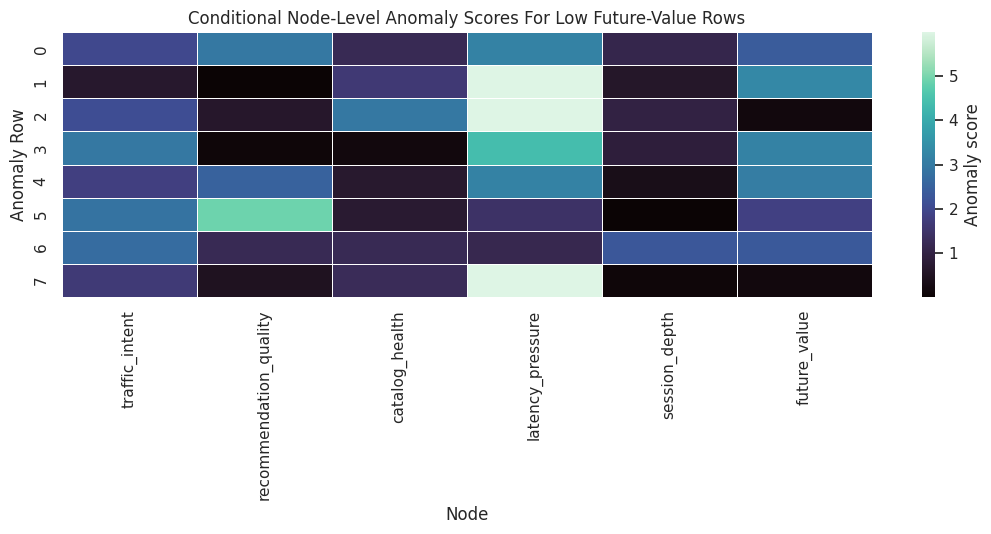

In [12]:
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(
    anomaly_score_table.set_index("anomaly_row"),
    cmap="mako",
    linewidths=0.4,
    cbar_kws={"label": "Anomaly score"},
    ax=ax,
)
ax.set_title("Conditional Node-Level Anomaly Scores For Low Future-Value Rows")
ax.set_xlabel("Node")
ax.set_ylabel("Anomaly Row")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "13_node_level_anomaly_scores_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()


The heatmap separates row-specific stories. Some low-value rows are primarily explained by root conditions, while others may include unusual downstream residual behavior.

The causal implication is indirect but important: these diagnostics tell us whether the modeling stage is stable enough to support the causal estimate.
<!-- result-implication-expanded -->




#### Attribute Target Anomalies to Upstream Nodes

`gcm.attribute_anomalies` attributes the anomaly score of a target node to upstream nodes and the target node's own residual noise. Because the model is invertible, DoWhy can reconstruct noise values for the anomalous rows and estimate Shapley-style contributions.

In [13]:
# Smaller Shapley settings keep the tutorial fast while preserving the qualitative attribution pattern.
shapley_config = gcm.shapley.ShapleyConfig(
    num_permutations=12,
    num_subset_samples=250,
    n_jobs=1,
)

anomaly_attribution_dict = gcm.attribute_anomalies(
    reference_model,
    target_node="future_value",
    anomaly_samples=anomaly_samples,
    num_distribution_samples=600,
    shapley_config=shapley_config,
)

anomaly_attribution_table = pd.DataFrame(anomaly_attribution_dict).reset_index(names="anomaly_row")
anomaly_attribution_table.to_csv(TABLE_DIR / "13_target_anomaly_attributions_by_row.csv", index=False)
display(anomaly_attribution_table)

,anomaly_row,traffic_intent,catalog_health,latency_pressure,recommendation_quality,session_depth,future_value
0,0,1.6112,0.6905,1.7329,1.1770,0.4089,1.4704
1,1,0.1834,0.6693,4.3214,-0.0279,0.2338,1.7109
2,2,1.8748,1.5097,2.8619,0.2582,0.3129,0.2734
3,3,2.5454,-0.3901,2.4941,0.2338,0.3863,1.8214
4,4,1.3835,0.4160,1.5843,1.4744,0.1469,2.0860
5,5,2.5117,0.5030,0.1046,2.6157,-0.1134,1.4692
6,6,2.5368,0.9243,0.0596,0.6312,1.0008,1.9382
7,7,1.0065,0.8898,4.4311,0.3339,0.0319,0.3978


Each row's target anomaly is decomposed across upstream nodes and the target residual. Positive contributions increase the target anomaly score; small or negative values indicate little contribution under this attribution setup.

#### Summarize Anomaly Attributions

For a small incident review, row-level details matter. For a quick root-cause summary, average absolute and signed contributions across the selected anomalous rows are easier to read.

In [14]:
anomaly_attribution_long = anomaly_attribution_table.melt(
    id_vars="anomaly_row",
    var_name="node",
    value_name="contribution",
)

anomaly_attribution_summary = (
    anomaly_attribution_long.groupby("node")
    .agg(
        mean_contribution=("contribution", "mean"),
        mean_absolute_contribution=("contribution", lambda values: np.mean(np.abs(values))),
        max_contribution=("contribution", "max"),
    )
    .reset_index()
    .sort_values("mean_absolute_contribution", ascending=False)
)

anomaly_attribution_summary.to_csv(TABLE_DIR / "13_target_anomaly_attribution_summary.csv", index=False)
display(anomaly_attribution_summary)


,node,mean_contribution,mean_absolute_contribution,max_contribution
2,latency_pressure,2.1987,2.1987,4.4311
5,traffic_intent,1.7067,1.7067,2.5454
1,future_value,1.3959,1.3959,2.0860
3,recommendation_quality,0.8370,0.8440,2.6157
0,catalog_health,0.6516,0.7491,1.5097
4,session_depth,0.3010,0.3293,1.0008


The summary ranks the strongest contributors to the selected low future-value anomalies. In this simulation, low traffic intent, catalog weakness, and latency pressure should appear as important upstream explanations.

#### Plot Mean Anomaly Attribution

This chart turns the attribution summary into a ranked root-cause view. The absolute scale is model-specific, so the ranking and relative size are more useful than the raw units.

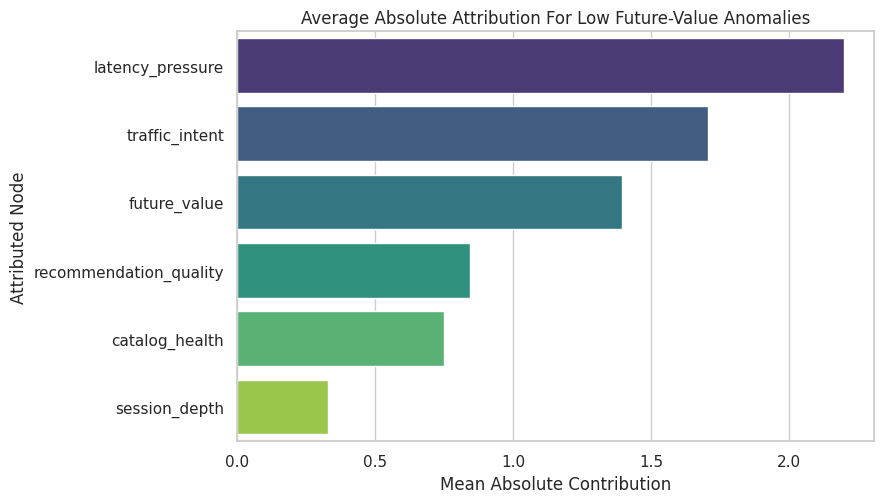

In [15]:
fig, ax = plt.subplots(figsize=(9, 5.2))
sns.barplot(
    data=anomaly_attribution_summary,
    x="mean_absolute_contribution",
    y="node",
    hue="node",
    dodge=False,
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.set_title("Average Absolute Attribution For Low Future-Value Anomalies")
ax.set_xlabel("Mean Absolute Contribution")
ax.set_ylabel("Attributed Node")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "13_average_anomaly_attribution.png", dpi=160, bbox_inches="tight")
plt.show()


The plot gives a row-level incident story: among the selected extreme rows, the strongest explanations are the nodes with the largest anomaly-attribution contributions.

The figure matters because it turns the numeric output into a pattern that can be inspected before trusting the next modeling step.
<!-- result-implication-expanded -->




#### Compare Row-Level Values and Attributions

Root-cause results are easier to audit when attributions are shown next to the original anomalous values. This table joins the selected rows with their largest attribution contributor.

In [16]:
top_contributor_by_row = (
    anomaly_attribution_long.assign(abs_contribution=lambda frame: frame["contribution"].abs())
    .sort_values(["anomaly_row", "abs_contribution"], ascending=[True, False])
    .groupby("anomaly_row")
    .head(1)
    .rename(columns={"node": "top_attributed_node", "contribution": "top_attribution"})
    [["anomaly_row", "top_attributed_node", "top_attribution"]]
)

anomaly_audit_table = anomaly_samples.reset_index(names="anomaly_row").merge(
    top_contributor_by_row,
    on="anomaly_row",
    how="left",
)

anomaly_audit_table.to_csv(TABLE_DIR / "13_anomaly_audit_table.csv", index=False)
display(anomaly_audit_table)


,anomaly_row,traffic_intent,catalog_health,latency_pressure,recommendation_quality,session_depth,future_value,top_attributed_node,top_attribution
0,0,-1.6868,-1.0211,1.9740,-3.6013,-4.2767,-6.0933,latency_pressure,1.7329
1,1,-0.7594,-1.3497,3.3312,-3.0751,-3.8410,-5.9036,latency_pressure,4.3214
2,2,-1.8228,-1.9670,2.5293,-3.9185,-4.5886,-5.7084,latency_pressure,2.8619
3,3,-2.2549,0.2372,2.3927,-2.4273,-3.7330,-5.6638,traffic_intent,2.5454
4,4,-1.4953,-0.6883,1.9845,-3.1921,-3.6082,-5.5982,future_value,2.0860
5,5,-2.1893,-0.7117,1.2206,-3.6108,-3.6397,-5.5455,recommendation_quality,2.6157
6,6,-2.0970,-1.0511,1.0655,-2.9025,-3.9922,-5.5202,traffic_intent,2.5368
7,7,-1.4380,-1.1261,3.4270,-3.6518,-4.2777,-5.5121,latency_pressure,4.4311


This audit view makes it harder to overtrust a black-box ranking. We can inspect whether the top attributed node is plausible given the actual row values.

#### Distribution-Change Attribution Setup

Anomaly attribution explained a few low-value rows. Now we switch to a population question: why did the distribution of `future_value` change from the old period to the new period?

We use a signed mean difference function so the attributions are in the same direction as the target mean change.

In [17]:
def signed_mean_difference(old_samples, new_samples):
    """
    Return new mean minus old mean for one-dimensional sample arrays.
    
    Parameters
    ----------
    old_samples : object
        Reference sample drawn before the distribution shift.
    new_samples : object
        Comparison sample drawn after the distribution shift.
    
    Returns
    -------
    float
        Signed difference in feature means between the new sample and the old reference sample.
    """
    return float(np.mean(new_samples) - np.mean(old_samples))

observed_target_shift = signed_mean_difference(
    old_causal_data["future_value"].to_numpy(),
    new_causal_data["future_value"].to_numpy(),
)

print(f"Observed future_value mean shift, new minus old: {observed_target_shift:.4f}")


Observed future_value mean shift, new minus old: -1.0808


The observed mean shift is negative, meaning future value decreased in the new period. Distribution-change attribution will decompose that decrease across nodes in the graph.

#### Run DoWhy Distribution-Change Attribution

`gcm.distribution_change` fits old and new versions of the causal mechanisms and estimates how much each node contributes to the target distribution change. We request additional information so we can also see which node mechanisms DoWhy flags as changed.

In [18]:
# Save the artifacts produced by the Run DoWhy Distribution-Change Attribution section.
distribution_attributions, mechanism_changes, old_fitted_model, new_fitted_model = gcm.distribution_change(
    reference_model,
    old_data=old_causal_data,
    new_data=new_causal_data,
    target_node="future_value",
    num_samples=350,
    difference_estimation_func=signed_mean_difference,
    return_additional_info=True,
    shapley_config=shapley_config,
)

distribution_change_table = (
    pd.DataFrame(
        [
            {
                "node": node,
                "signed_contribution": contribution,
                "absolute_contribution": abs(contribution),
                "mechanism_flagged_as_changed": bool(mechanism_changes.get(node, False)),
            }
            for node, contribution in distribution_attributions.items()
        ]
    )
    .sort_values("absolute_contribution", ascending=False)
    .reset_index(drop=True)
)

distribution_change_table.to_csv(TABLE_DIR / "13_distribution_change_attribution.csv", index=False)
display(distribution_change_table)


,node,signed_contribution,absolute_contribution,mechanism_flagged_as_changed
0,latency_pressure,-0.5222,0.5222,True
1,catalog_health,-0.3422,0.3422,True
2,recommendation_quality,-0.2032,0.2032,True
3,traffic_intent,-0.0597,0.0597,False
4,session_depth,0.0455,0.0455,False
5,future_value,0.0125,0.0125,False


The signed contributions explain the direction of the target shift. Negative values push the new target mean lower than the old target mean; positive values offset the decline.



#### Check the Attribution Sum

For a signed mean-change attribution, the sum of node contributions should be close to the estimated target mean shift. Small differences can appear because attribution is estimated with sampling.

In [19]:
attribution_sum = distribution_change_table["signed_contribution"].sum()

sum_check = pd.DataFrame(
    [
        {
            "quantity": "observed new minus old mean shift",
            "value": observed_target_shift,
        },
        {
            "quantity": "sum of distribution-change attributions",
            "value": attribution_sum,
        },
        {
            "quantity": "absolute difference",
            "value": abs(observed_target_shift - attribution_sum),
        },
    ]
)

sum_check.to_csv(TABLE_DIR / "13_distribution_change_sum_check.csv", index=False)
display(sum_check)


,quantity,value
0,observed new minus old mean shift,-1.0808
1,sum of distribution-change attributions,-1.0692
2,absolute difference,0.0116


The attribution sum should be close enough for learning purposes. In production analysis, we would increase sampling settings and repeat the attribution to check stability.



#### Plot Distribution-Change Attributions

A signed bar chart makes it clear which nodes push the target down and which nodes push it up. The graph determines how upstream changes propagate to the target.

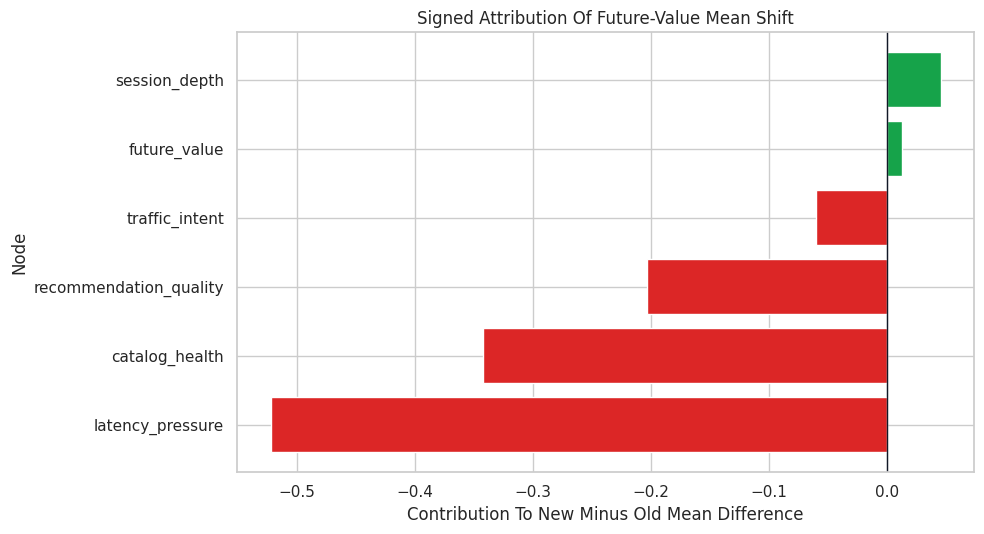

In [20]:
plot_distribution_table = distribution_change_table.sort_values("signed_contribution")

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ["#dc2626" if value < 0 else "#16a34a" for value in plot_distribution_table["signed_contribution"]]
ax.barh(
    plot_distribution_table["node"],
    plot_distribution_table["signed_contribution"],
    color=colors,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Signed Attribution Of Future-Value Mean Shift")
ax.set_xlabel("Contribution To New Minus Old Mean Difference")
ax.set_ylabel("Node")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "13_distribution_change_attribution.png", dpi=160, bbox_inches="tight")
plt.show()


The strongest negative contributors are the causal explanations for the population-level decline. This is a different question from the row-level anomaly attribution earlier.

The figure matters because it turns the numeric output into a pattern that can be inspected before trusting the next modeling step.
<!-- result-implication-expanded -->




#### Inspect Mechanism-Change Flags

DoWhy also returns flags indicating whether each node's mechanism appears to have changed between old and new data. Root node flags indicate marginal distribution changes; non-root flags indicate changed conditional mechanisms.

In [21]:
mechanism_change_table = pd.DataFrame(
    [
        {
            "node": node,
            "is_root_node": causal_graph.in_degree(node) == 0,
            "flagged_as_changed": bool(changed),
            "plain_reading": "root distribution changed" if causal_graph.in_degree(node) == 0 else "conditional mechanism changed",
        }
        for node, changed in mechanism_changes.items()
    ]
).sort_values(["flagged_as_changed", "node"], ascending=[False, True])

mechanism_change_table.to_csv(TABLE_DIR / "13_mechanism_change_flags.csv", index=False)
display(mechanism_change_table)


,node,is_root_node,flagged_as_changed,plain_reading
2,catalog_health,True,True,root distribution changed
3,latency_pressure,True,True,root distribution changed
1,recommendation_quality,False,True,conditional mechanism changed
5,future_value,False,False,conditional mechanism changed
4,session_depth,False,False,conditional mechanism changed
0,traffic_intent,True,False,root distribution changed


The flags should identify catalog health and latency pressure as root shifts, and recommendation quality as a changed mechanism. That matches the way the new-period data were generated.

#### Robust Mean-Shift Attribution

`gcm.distribution_change_robust` provides another way to attribute changes in a target functional. Here we use the target mean and regression mode. This is useful as a complementary check rather than a replacement for the previous attribution.

In [22]:
# Save the artifacts produced by the Robust Mean-Shift Attribution section.
robust_attributions = gcm.distribution_change_robust(
    reference_model,
    old_data=old_causal_data,
    new_data=new_causal_data,
    target_node="future_value",
    target_functional="mean",
    xfit=False,
    method="regression",
    shapley_config=shapley_config,
)

robust_change_table = (
    pd.DataFrame(
        [
            {
                "node": node,
                "robust_signed_contribution": contribution,
                "robust_absolute_contribution": abs(contribution),
            }
            for node, contribution in robust_attributions.items()
        ]
    )
    .sort_values("robust_absolute_contribution", ascending=False)
    .reset_index(drop=True)
)

robust_change_table.to_csv(TABLE_DIR / "13_distribution_change_robust_attribution.csv", index=False)
display(robust_change_table)


,node,robust_signed_contribution,robust_absolute_contribution
0,latency_pressure,-0.6528,0.6528
1,catalog_health,-0.3737,0.3737
2,recommendation_quality,-0.2125,0.2125
3,traffic_intent,0.0918,0.0918
4,future_value,0.0126,0.0126
5,session_depth,-0.0048,0.0048


The robust attribution is another view of the mean shift. We should expect the exact numbers to differ, but the leading contributors should tell a similar story if the signal is strong.



#### Compare Standard and Robust Distribution Attributions

The next table joins the two distribution-change methods. Agreement in the largest contributors strengthens the diagnostic story; disagreement is a prompt for sensitivity checks.

In [23]:
method_comparison = distribution_change_table[["node", "signed_contribution"]].merge(
    robust_change_table[["node", "robust_signed_contribution"]],
    on="node",
    how="outer",
).fillna(0)

method_comparison["same_direction"] = np.sign(method_comparison["signed_contribution"]) == np.sign(
    method_comparison["robust_signed_contribution"]
)
method_comparison["combined_abs_rank_score"] = (
    method_comparison["signed_contribution"].abs()
    + method_comparison["robust_signed_contribution"].abs()
)
method_comparison = method_comparison.sort_values("combined_abs_rank_score", ascending=False).reset_index(drop=True)

method_comparison.to_csv(TABLE_DIR / "13_distribution_method_comparison.csv", index=False)
display(method_comparison)


,node,signed_contribution,robust_signed_contribution,same_direction,combined_abs_rank_score
0,latency_pressure,-0.5222,-0.6528,True,1.1750
1,catalog_health,-0.3422,-0.3737,True,0.7158
2,recommendation_quality,-0.2032,-0.2125,True,0.4157
3,traffic_intent,-0.0597,0.0918,False,0.1516
4,session_depth,0.0455,-0.0048,False,0.0504
5,future_value,0.0125,0.0126,True,0.0251


The comparison is a compact stability check. We are looking for the same main story, not identical values from two different attribution procedures.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->


#### Plot Method Comparison

This side-by-side plot shows whether the standard and robust attributions agree on the leading causes of the mean shift.

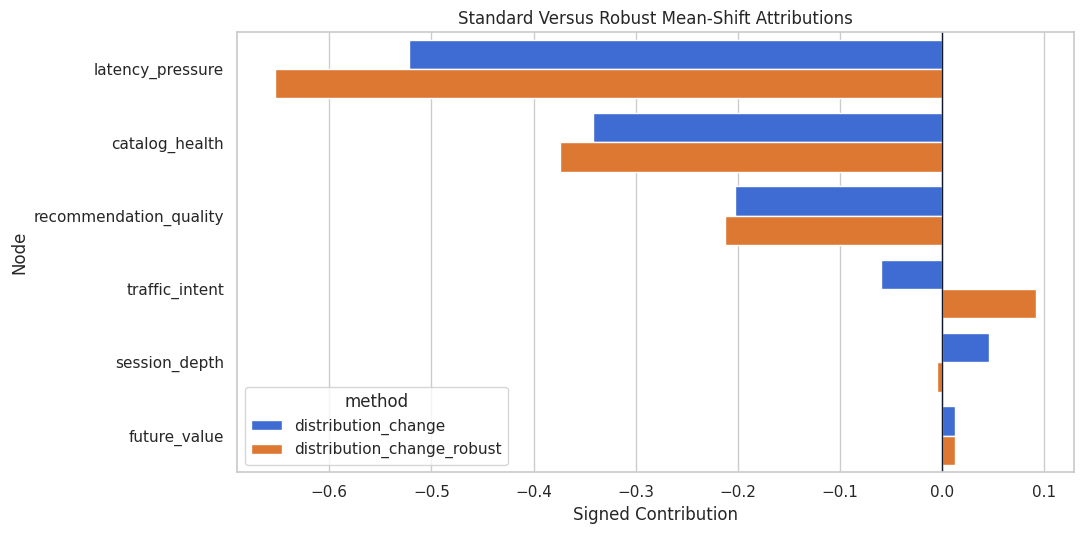

In [24]:
# Build and label the diagnostic visualization for the Plot Method Comparison section.
comparison_plot_df = method_comparison.melt(
    id_vars="node",
    value_vars=["signed_contribution", "robust_signed_contribution"],
    var_name="method",
    value_name="signed_contribution_value",
)
comparison_plot_df["method"] = comparison_plot_df["method"].replace(
    {
        "signed_contribution": "distribution_change",
        "robust_signed_contribution": "distribution_change_robust",
    }
)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(
    data=comparison_plot_df,
    x="signed_contribution_value",
    y="node",
    hue="method",
    palette=["#2563eb", "#f97316"],
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Standard Versus Robust Mean-Shift Attributions")
ax.set_xlabel("Signed Contribution")
ax.set_ylabel("Node")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "13_standard_vs_robust_distribution_change.png", dpi=160, bbox_inches="tight")
plt.show()


The methods should agree that latency pressure, catalog health, and recommendation quality are central to the target decline. That is the high-level root-cause message.



#### Row-Level and Population-Level Stories Side by Side

The same node can matter differently for selected anomalies and for the full-period distribution shift. This table compares the anomaly summary with distribution-change attribution.

In [25]:
side_by_side = anomaly_attribution_summary[["node", "mean_absolute_contribution"]].merge(
    distribution_change_table[["node", "signed_contribution", "absolute_contribution", "mechanism_flagged_as_changed"]],
    on="node",
    how="outer",
).fillna(0)

side_by_side = side_by_side.sort_values("absolute_contribution", ascending=False).reset_index(drop=True)
side_by_side.to_csv(TABLE_DIR / "13_anomaly_vs_distribution_change_summary.csv", index=False)
display(side_by_side)

,node,mean_absolute_contribution,signed_contribution,absolute_contribution,mechanism_flagged_as_changed
0,latency_pressure,2.1987,-0.5222,0.5222,True
1,catalog_health,0.7491,-0.3422,0.3422,True
2,recommendation_quality,0.8440,-0.2032,0.2032,True
3,traffic_intent,1.7067,-0.0597,0.0597,False
4,session_depth,0.3293,0.0455,0.0455,False
5,future_value,1.3959,0.0125,0.0125,False


This comparison prevents overgeneralization. A node that explains the worst individual rows is not always the largest driver of the overall population shift, and vice versa.

#### Practical Incident Narrative

The next cell turns the analysis into a short, structured narrative. This is the kind of summary that can sit above the figures in a report or investigation notebook.

In [26]:
# Save the artifacts produced by the Practical Incident Narrative section.
top_distribution_nodes = distribution_change_table.head(3)["node"].tolist()
top_anomaly_nodes = anomaly_attribution_summary.head(3)["node"].tolist()
changed_nodes = mechanism_change_table.loc[mechanism_change_table["flagged_as_changed"], "node"].tolist()

incident_narrative = pd.DataFrame(
    [
        {
            "section": "Observed symptom",
            "summary": f"Future value decreased by {observed_target_shift:.3f} on average in the new period.",
        },
        {
            "section": "Population-level drivers",
            "summary": ", ".join(top_distribution_nodes),
        },
        {
            "section": "Worst-row anomaly drivers",
            "summary": ", ".join(top_anomaly_nodes),
        },
        {
            "section": "Mechanisms flagged as changed",
            "summary": ", ".join(changed_nodes),
        },
        {
            "section": "Recommended next diagnostic step",
            "summary": "Inspect latency, catalog-health, and recommendation-quality pipelines before treating session depth as the original cause.",
        },
    ]
)

incident_narrative.to_csv(TABLE_DIR / "13_incident_narrative.csv", index=False)
display(incident_narrative)


,section,summary
0,Observed symptom,Future value decreased by -1.081 on average in the new period.
1,Population-level drivers,"latency_pressure, catalog_health, recommendation_quality"
2,Worst-row anomaly drivers,"latency_pressure, traffic_intent, future_value"
3,Mechanisms flagged as changed,"catalog_health, latency_pressure, recommendation_quality"
4,Recommended next diagnostic step,"Inspect latency, catalog-health, and recommendation-quality pipelines before treating session depth as the original cause."


This narrative names the metric movement, the population drivers, the row-level anomaly drivers, and the next diagnostic step. That is more useful than a plot without a decision-oriented summary.




## Reporting and Takeaways

### Assumption and Failure-Mode Checklist

Root-cause attribution is only as credible as the causal graph and fitted mechanisms. The checklist below captures the main risks to report alongside results.

| check | why it matters | what to do |
| --- | --- | --- |
| Graph direction is credible | Attribution follows directed paths. A reversed edge can turn a symptom into a false cause. | Validate timing and mechanism ownership with domain experts. |
| Reference period is genuinely normal | Anomaly scoring is relative to the fitted baseline system. | Fit on a stable period and rerun on alternative baselines. |
| Mechanisms fit reasonably well | Poor mechanism fit can create residual anomalies that are model artifacts. | Compare generated samples, residuals, and mechanism performance. |
| Attributions are stable | Shapley estimates use sampling and can vary with settings. | Repeat with larger sample settings or multiple seeds for final reporting. |
| Population and row-level questions are separated | Worst-row root causes and overall shift drivers can differ. | Report anomaly attribution and distribution-change attribution separately. |
| Operational action is testable | Attribution is diagnostic, not proof that a fix will work. | Use follow-up experiments, rollback tests, or targeted monitoring. |


The checklist is intentionally practical. Root-cause analysis can sound definitive, so every result should be paired with the checks that would make it actionable.

### Final Summary

This lesson used DoWhy GCM tools for causal root-cause analysis:

- `gcm.anomaly_scores` identified which nodes looked unusual for selected low-outcome rows.
- `gcm.attribute_anomalies` attributed target anomalies to upstream nodes and target residual noise.
- `gcm.distribution_change` decomposed the population-level target shift between old and new data.
- `gcm.distribution_change_robust` provided a complementary mean-shift attribution check.
- The side-by-side comparison showed why row-level anomaly stories and population-level shift stories should be reported separately.

The next tutorial is an end-to-end observational case study that combines graph design, identification, estimation, diagnostics, refutation, and reporting in one compact workflow.